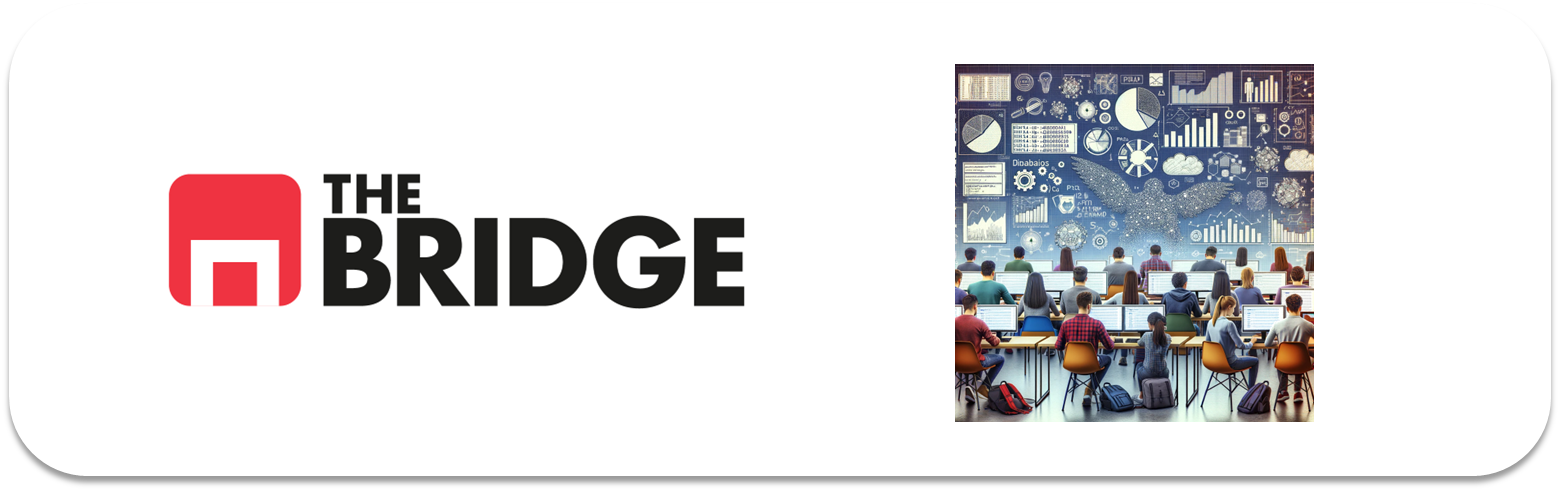

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
sns.set_style('whitegrid')

1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.

In [44]:
casas = pd.read_csv('data/hard_to_find/obligatoria_hard.csv',sep='|')
casas.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [45]:
casas.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [46]:
casas.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.

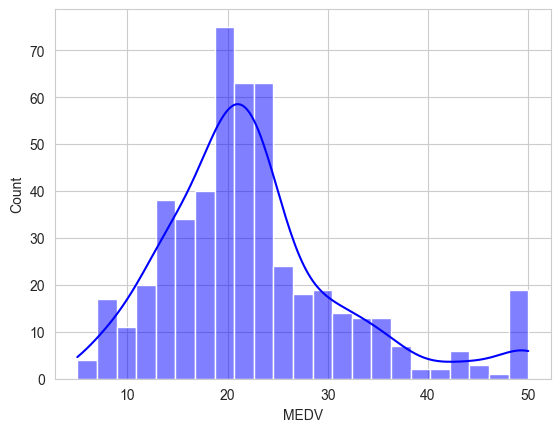

In [47]:
sns.histplot(casas['MEDV'], color='Blue', kde = True)
plt.show()

In [48]:
casas = casas[casas['MEDV'] < 50]

La distribución parece normal si no fuera por la cola en los valores alto, lo que indica que probablemente hay un agrupamiento de todos los valores que son mayores de 50 y equipararlo a 50. Seguiremos para adelante pero tendremos en cuenta que nos puede desvirtuar las predicciones, por lo que puede que tengamos que eliminar datos

3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test

In [49]:
features = casas.drop('MEDV', axis=1)
target = casas['MEDV']
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [50]:
features_train.shape, features_test.shape, target_train.shape, target_test.shape

((392, 12), (98, 12), (392,), (98,))

5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

MEDV       1.000000
LSTAT     -0.759837
RM         0.686634
INDUS     -0.600005
TAX       -0.572442
NOX       -0.524451
PTRATIO   -0.518641
AGE       -0.492915
RAD       -0.476296
CRIM      -0.450115
ZN         0.404608
DIS        0.368813
CHAS       0.074803
Name: MEDV, dtype: float64


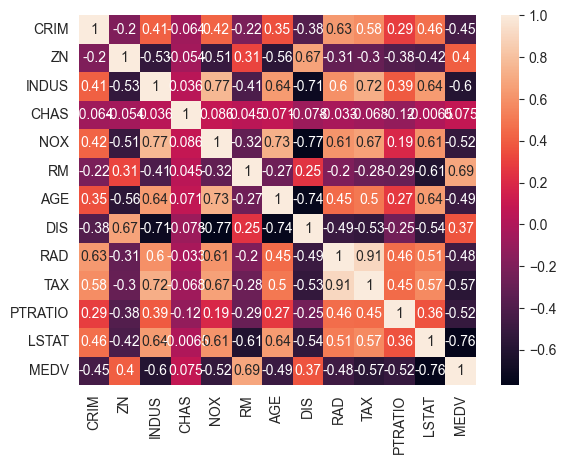

In [51]:
correlacion = casas.corr(numeric_only= True)
print(correlacion['MEDV'].sort_values(ascending=False, key=abs))
sns.heatmap(correlacion,annot=True);
plt.show();

6. Trata las variables para que funcionen lo mejor posible en el modelo.

Voy a filtrar todas las variables que tengan menos de 0.4 de correlación en valor absoluto

In [52]:
# Selecciono las variables cuya correlación absoluta con MEDV es > 0.4
selected_features = correlacion['MEDV'][abs(correlacion['MEDV']) > 0.41].index.tolist()
# Quito 'MEDV' porque es la variable objetivo, no una característica
selected_features.remove('MEDV')
# Quito 'RAD' porque desconocemos su significado y no queremos incluirla sin entenderla
selected_features.remove('RAD')
# Filtro X_train y X_test para quedarme solo con las features seleccionadas
features_train = features_train[selected_features]
features_test = features_test[selected_features]

# Muestro las features seleccionadas y las dimensiones de los conjuntos resultantes
print("Selected features:", selected_features)
print("Features train shape:", features_train.shape)
print("Features test shape:", features_test.shape)

Selected features: ['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'TAX', 'PTRATIO', 'LSTAT']
Features train shape: (392, 8)
Features test shape: (98, 8)


In [53]:
criterio_col = 0.7
excluidas = []
corr_numeric = features_train[selected_features].corr(numeric_only = True)

for col in selected_features:
    print(f"Comprobando colinealidad de {col}")
    if col not in excluidas:
        for col_2, valor_corr in corr_numeric[col].items():
            print(f"\tComprobando {col} con {col_2}")
            if col != col_2 and col_2 in selected_features:
                if np.abs(valor_corr) >= criterio_col:
                    print(f"\t\t--> {col} correla con {col_2} al {valor_corr:0.4f}, EXCLUIMOS {col_2} <--")
                    excluidas.append(col_2)
                else:
                    print(f"\t\t{col} correla con {col_2} al {valor_corr:0.4f}, mantenemos {col_2}")
            elif col == col_2:
                print("\t\tSon la misma variable, no comprobamos")
    
    elif col in excluidas:
        print(f"\tLa columna {col} ya ha sido excluida")

excluidas = list(set(excluidas))
print("\nLas variables a excluir son", excluidas)

Comprobando colinealidad de CRIM
	Comprobando CRIM con CRIM
		Son la misma variable, no comprobamos
	Comprobando CRIM con INDUS
		CRIM correla con INDUS al 0.4232, mantenemos INDUS
	Comprobando CRIM con NOX
		CRIM correla con NOX al 0.4306, mantenemos NOX
	Comprobando CRIM con RM
		CRIM correla con RM al -0.2519, mantenemos RM
	Comprobando CRIM con AGE
		CRIM correla con AGE al 0.3542, mantenemos AGE
	Comprobando CRIM con TAX
		CRIM correla con TAX al 0.6014, mantenemos TAX
	Comprobando CRIM con PTRATIO
		CRIM correla con PTRATIO al 0.2951, mantenemos PTRATIO
	Comprobando CRIM con LSTAT
		CRIM correla con LSTAT al 0.4688, mantenemos LSTAT
Comprobando colinealidad de INDUS
	Comprobando INDUS con CRIM
		INDUS correla con CRIM al 0.4232, mantenemos CRIM
	Comprobando INDUS con INDUS
		Son la misma variable, no comprobamos
	Comprobando INDUS con NOX
		--> INDUS correla con NOX al 0.7714, EXCLUIMOS NOX <--
	Comprobando INDUS con RM
		INDUS correla con RM al -0.4233, mantenemos RM
	Comproband


Las variables seleccionadas para el modelo son ['CRIM', 'INDUS', 'RM', 'AGE', 'PTRATIO', 'LSTAT']


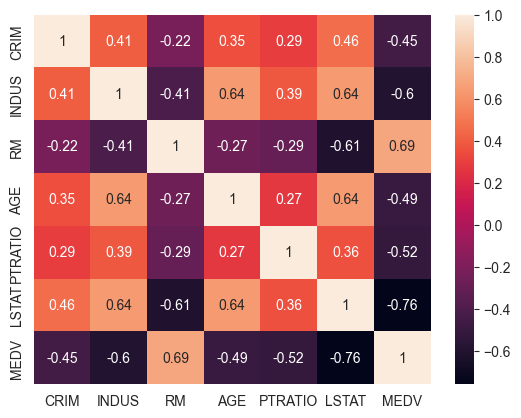

In [54]:
selected_features = [col for col in selected_features if col not in excluidas]
print("\nLas variables seleccionadas para el modelo son", selected_features)
casas_filtered = casas[selected_features + ['MEDV']]
correlacion = casas_filtered.corr(numeric_only= True)
sns.heatmap(correlacion,annot=True);
plt.show();

In [55]:
# Filtro X_train y X_test para quedarme solo con las features seleccionadas
features_train = features_train[selected_features]
features_test = features_test[selected_features]


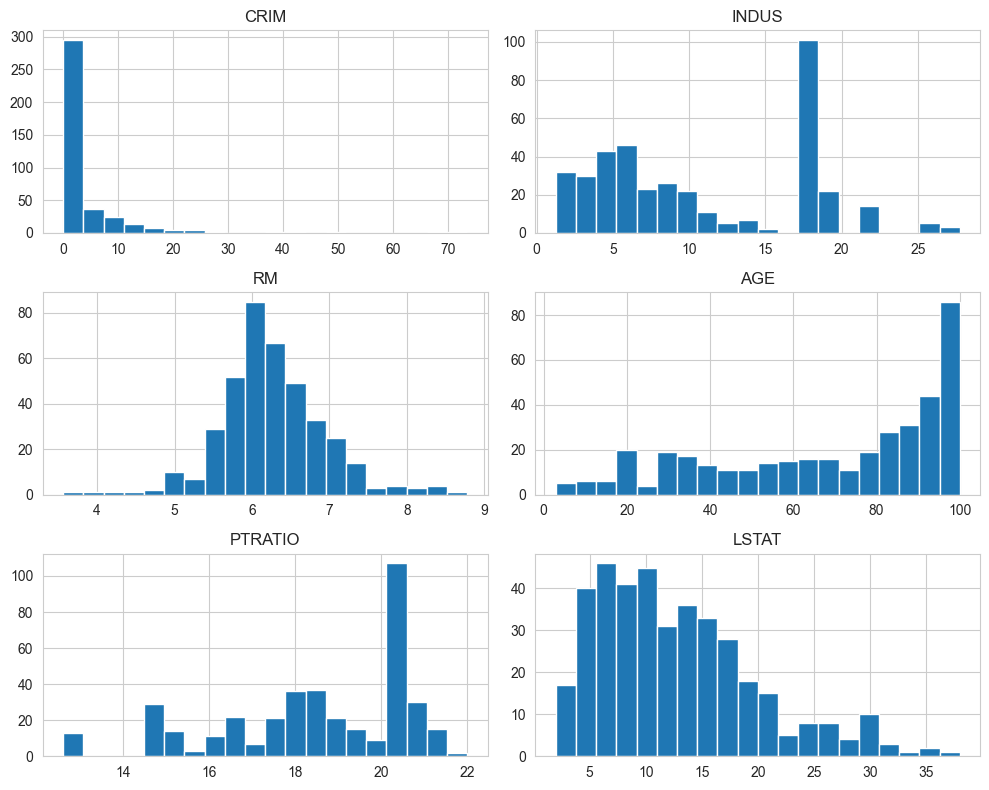

In [56]:
features_train[selected_features].hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()

In [57]:
print("\n" + "=" * 60)
print("ASIMETRÍA DE FEATURES SELECCIONADAS")
print("=" * 60)
skew = features_train[selected_features].skew().sort_values(ascending=False)
for feat, val in skew.items():
    flag = "→ transformar" if abs(val) > 0.9 else "→ OK"
    print(f"  {feat:>8}  skew = {val:6.3f}  {flag}")


ASIMETRÍA DE FEATURES SELECCIONADAS
      CRIM  skew =  4.825  → transformar
     LSTAT  skew =  0.945  → transformar
     INDUS  skew =  0.331  → OK
        RM  skew =  0.209  → OK
       AGE  skew = -0.628  → OK
   PTRATIO  skew = -0.768  → OK


Transformando LSTAT con logaritmo
Transformando CRIM con logaritmo


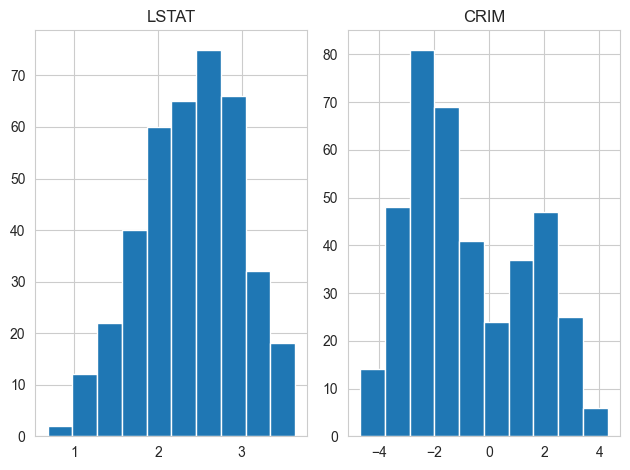

In [58]:
features_transform = ["LSTAT","CRIM"]

for feature in features_transform:
    print(f"Transformando {feature} con logaritmo")
    features_train[feature] = features_train[feature].apply(np.log)
    features_test[feature] = features_test[feature].apply(np.log)

features_train[features_transform].hist()
plt.tight_layout();

In [59]:
scaler = StandardScaler()
scaler.fit(features_train[selected_features])

features_train[selected_features] = scaler.fit_transform(features_train[selected_features])
features_test[selected_features] = scaler.transform(features_test[selected_features])

7. Construye un modelo de regresión lineal.

In [60]:
lm = LinearRegression()
lm.fit(features_train, target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


8. Analiza si lo crees conveniente los pesos y la importancia de las features.

In [61]:
lm.intercept_

np.float64(22.028826530612243)

In [62]:
lm.coef_

array([-0.60175475, -0.44559774,  1.9350991 ,  0.76718913, -1.64592407,
       -4.41345311])

In [63]:
coef_df = pd.DataFrame(lm.coef_, features_train.columns, 
                      columns=['Coefficient'])
coef_df

,Coefficient
CRIM,-0.601755
INDUS,-0.445598
RM,1.935099
AGE,0.767189
PTRATIO,-1.645924
LSTAT,-4.413453


9. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.

In [64]:
pred_train = lm.predict(features_train)
print('MAE train', metrics.mean_absolute_error(target_train, pred_train))
print('MSE train', metrics.mean_squared_error(target_train, pred_train))
print('MAPE train', metrics.mean_absolute_percentage_error(target_train, pred_train)*100, "%")
print('RMSE train', np.sqrt(metrics.mean_squared_error(target_train, pred_train)))
print('R2 train', lm.score(features_train, target_train))

MAE train 2.9748600461970205
MSE train 15.222940569086644
MAPE train 15.79130672003653 %
RMSE train 3.901658694592166
R2 train 0.7607496546462653


In [65]:
pred_test = lm.predict(features_test)
print('MAE test', metrics.mean_absolute_error(target_test, pred_test))
print('MSE test', metrics.mean_squared_error(target_test, pred_test))
print('MAPE test', metrics.mean_absolute_percentage_error(target_test, pred_test)*100, "%")
print('RMSE test', np.sqrt(metrics.mean_squared_error(target_test, pred_test)))
print('R2 test', lm.score(features_test, target_test))

MAE test 2.8529610502689198
MSE test 13.513403862851405
MAPE test 16.548088444881728 %
RMSE test 3.6760581963363155
R2 test 0.7354740258532013


10. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.

### Ridge

In [66]:
ridgeR = Ridge(alpha = 10) # alpha es lambda 
ridgeR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE:", round(metrics.mean_squared_error(target_train, ridgeR.predict(features_train)),2))
print("Test MSE:", round(metrics.mean_squared_error(target_test, ridgeR.predict(features_test)),2))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(target_test, ridgeR.predict(features_test))))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.25
Test MSE: 13.48


In [67]:
ridgeR = Ridge(alpha = 5) # alpha es lambda 
ridgeR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE:", round(metrics.mean_squared_error(target_train, ridgeR.predict(features_train)),2))
print("Test MSE:", round(metrics.mean_squared_error(target_test, ridgeR.predict(features_test)),2))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(target_test, ridgeR.predict(features_test))))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.23
Test MSE: 13.49


In [68]:
ridgeR = Ridge(alpha = 15) # alpha es lambda 
ridgeR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE:", round(metrics.mean_squared_error(target_train, ridgeR.predict(features_train)),2))
print("Test MSE:", round(metrics.mean_squared_error(target_test, ridgeR.predict(features_test)),2))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(target_test, ridgeR.predict(features_test))))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.28
Test MSE: 13.48


### LASSO

In [69]:
lassoR = Lasso(alpha=0.1)
lassoR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, lassoR.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, lassoR.predict(features_test)))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.3088
Test MSE: 13.3753


In [70]:
lassoR = Lasso(alpha=0.07)
lassoR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, lassoR.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, lassoR.predict(features_test)))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.2650
Test MSE: 13.4013


In [71]:
lassoR = Lasso(alpha=0.5)
lassoR.fit(features_train, target_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, lassoR.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, lassoR.predict(features_test)))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.9245
Test MSE: 13.7218


### Elastic Net

In [72]:
elastic_net = ElasticNet(alpha = 0.5, l1_ratio = 0.5)
elastic_net.fit(features_train, target_train)
print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, elastic_net.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, elastic_net.predict(features_test)))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 16.6201
Test MSE: 14.3186


In [73]:
elastic_net = ElasticNet(alpha = 0.05, l1_ratio = 0.5)
elastic_net.fit(features_train, target_train)
print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, elastic_net.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, elastic_net.predict(features_test)))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.2690
Test MSE: 13.4487


In [74]:
elastic_net = ElasticNet(alpha = 0.05, l1_ratio = 0.3)
elastic_net.fit(features_train, target_train)
print("Train MSE sin regularización:", round(metrics.mean_squared_error(target_train, lm.predict(features_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(target_test, lm.predict(features_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(target_train, elastic_net.predict(features_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(target_test, elastic_net.predict(features_test)))

Train MSE sin regularización: 15.22
Test MSE sin regularización: 13.51
Train MSE: 15.2854
Test MSE: 13.4629


11. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?

Ninguno de los tres métodos funciona especialmente bien, puesto que no se aprecia cambios significativos